# TabTransformer + GBDT 앙상블 — CUDA 버전 (RTX 5060 Ti 16GB)

확정 실험계획 반영본 (`C289039_유승환_TabTransformer_앙상블_실험계획.md`):
- **per-fold TT 재학습**(임베딩 누수 차단) + **GroupKFold(Race+Year)** 5-fold OOF
- 기본 피처만(FE 미적용) · 고정 하이퍼파라미터(Optuna 미적용)
- 가중 최적화 Soft Voting 앙상블 + Ablation(raw vs 임베딩)

**CUDA 최적화**: device 자동선택(cuda>mps>cpu), AMP(mixed precision), pin_memory, XGBoost GPU.

> ⚠️ 5060 Ti는 Blackwell(sm_120) → PyTorch cu128 빌드(2.7+) & CUDA 12.8+ 필요.
> `torch.cuda.is_available()`가 True인지 먼저 확인.

In [ ]:
import gc, copy
from contextlib import nullcontext
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix, roc_curve
from sklearn.metrics import ConfusionMatrixDisplay
import lightgbm as lgb
import xgboost as xgb
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda')


USE_AMP     = (device.type == 'cuda')         
PIN         = (device.type == 'cuda')          
NUM_WORKERS = 0                                
XGB_DEVICE  = 'cuda' if device.type == 'cuda' else 'cpu'

print('torch', torch.__version__, '| device', device, '| AMP', USE_AMP)
if device.type == 'cuda':
    print('GPU :', torch.cuda.get_device_name(0))

torch 2.11.0+cu128 | device cuda | AMP True
GPU : NVIDIA GeForce RTX 5060 Ti


## 실험 설정 코드

In [ ]:
# ════════════════════════════════════════════
#  실험 설정 — 이 셀만 수정하고 Run All
# ════════════════════════════════════════════
EXPERIMENT_CONFIG = {
    'experiment_name' : 'exp_fe_layers5_ff512_ep100',
    # TabTransformer 구조
    'n_layers'        : 5,
    'n_heads'         : 4,
    'dim_feedforward' : 512,
    'dropout'         : 0.1,
    # 학습
    'n_epochs'        : 100,
    'patience'        : 12,
    'batch_size'      : 4096,
    'lr'              : 2e-4,
    'weight_decay'    : 1e-4,
    'warmup_epochs'   : 5,
    'grad_clip'       : 1.0,
}
print(f"실험: {EXPERIMENT_CONFIG['experiment_name']}")
for k, v in EXPERIMENT_CONFIG.items():
    if k != 'experiment_name':
        print(f"  {k:<18}: {v}")

실험: exp_fe_layers3_ff512_ep60
  n_layers          : 3
  n_heads           : 4
  dim_feedforward   : 512
  dropout           : 0.15
  n_epochs          : 60
  patience          : 12
  batch_size        : 4096
  lr                : 0.0002
  weight_decay      : 0.0001
  warmup_epochs     : 5
  grad_clip         : 1.0


## 1. 데이터 로딩 & 전처리 (Step 1~2)

- 범주형 LabelEncoder는 train+test 합쳐 fit (unseen 방지, 누수 아님)
- **연속형 StandardScaler는 per-fold로 fit** → 여기서는 raw 값 유지, fold 루프 내부에서 스케일링
- `groups = Race + Year` → GroupKFold 키 (LSTM과 동일 CV)

In [3]:
data_path = './data/kaggle_data/'
train = pd.read_csv(data_path + 'train.csv')
test  = pd.read_csv(data_path + 'test.csv')
submission = pd.read_csv(data_path + 'sample_submission.csv')
print('Train', train.shape, '| Test', test.shape)

# ── 피처 정의 (Year → 범주형, 조합 피처 추가) ──
cat_features  = ['Driver', 'Compound', 'Race', 'Year',
                 'Driver_Compound', 'Driver_Race', 'Compound_Race', 'Driver_Compound_Race']
cont_features = ['LapNumber', 'Stint', 'TyreLife', 'Position',
                 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation',
                 'RaceProgress', 'Position_Change', 'PitStop',
                 'TyreLife_x_LapNumber', 'RaceProgress_x_TyreLife',
                 'LapDelta_DIV_LapTime', 'CumDeg_DIV_TyreLife', 'LapNumber_DIV_TyreLife']
target = 'PitNextLap'
emb_dim_map = {
    'Driver': 32, 'Compound': 4, 'Race': 8, 'Year': 4,
    'Driver_Compound': 32, 'Driver_Race': 32,
    'Compound_Race'  :  8, 'Driver_Compound_Race': 32,
}

# ── 피처 엔지니어링 ──
def add_features(df):
    df = df.copy()
    df['TyreLife_x_LapNumber']    = df['TyreLife'] * df['LapNumber']
    df['RaceProgress_x_TyreLife'] = df['RaceProgress'] * df['TyreLife']
    df['LapDelta_DIV_LapTime']    = df['LapTime_Delta'] / (df['LapTime (s)'] + 1e-6)
    df['CumDeg_DIV_TyreLife']     = df['Cumulative_Degradation'] / (df['TyreLife'] + 1e-6)
    df['LapNumber_DIV_TyreLife']  = df['LapNumber'] / (df['TyreLife'] + 1e-6)
    df['Driver_Compound']         = df['Driver'].astype(str) + '_' + df['Compound'].astype(str)
    df['Driver_Race']             = df['Driver'].astype(str) + '_' + df['Race'].astype(str)
    df['Compound_Race']           = df['Compound'].astype(str) + '_' + df['Race'].astype(str)
    df['Driver_Compound_Race']    = (df['Driver'].astype(str) + '_' +
                                     df['Compound'].astype(str) + '_' + df['Race'].astype(str))
    return df

all_data = pd.concat([train, test], ignore_index=True)
all_data = add_features(all_data)

# ── LabelEncoder (train+test 합쳐 fit) ──
cat_dims, cat_emb_dims = [], []
for col in cat_features:
    le = LabelEncoder()
    all_data[col + '_enc'] = le.fit_transform(all_data[col].astype(str))
    cat_dims.append(len(le.classes_))
    cat_emb_dims.append(emb_dim_map[col])

cat_enc_cols = [c + '_enc' for c in cat_features]
train_df = all_data.iloc[:len(train)].copy()
test_df  = all_data.iloc[len(train):].copy().reset_index(drop=True)

y = train[target].values.astype(np.float32)
groups = (train['Race'].astype(str) + '_' + train['Year'].astype(str)).values
pos_rate = y.mean()
spw = (1 - pos_rate) / pos_rate
print('cat_dims', dict(zip(cat_features, cat_dims)))
print('pos rate', round(float(pos_rate), 4), '| scale_pos_weight', round(spw, 3))
print('groups (Race+Year) 수:', len(np.unique(groups)))
print(f'cat_features: {len(cat_features)}개 | cont_features: {len(cont_features)}개')

Train (439140, 16) | Test (188165, 15)
cat_dims {'Driver': 887, 'Compound': 5, 'Race': 26, 'Year': 4, 'Driver_Compound': 3021, 'Driver_Race': 15408, 'Compound_Race': 100, 'Driver_Compound_Race': 35737}
pos rate 0.199 | scale_pos_weight 4.026
groups (Race+Year) 수: 104
cat_features: 8개 | cont_features: 15개


## 2. TabTransformer & Dataset 정의 (Step 3)

In [4]:
class TabTransformer(nn.Module):
    """범주형 Embedding -> Transformer Encoder -> 연속형 concat -> MLP."""
    def __init__(self, cat_dims, cat_emb_dims, n_continuous,
                 n_heads=None, n_layers=None, dim_feedforward=None, dropout=None):
        cfg = EXPERIMENT_CONFIG
        n_heads        = n_heads        or cfg['n_heads']
        n_layers       = n_layers       or cfg['n_layers']
        dim_feedforward= dim_feedforward or cfg['dim_feedforward']
        dropout        = dropout        if dropout is not None else cfg['dropout']
        super().__init__()
        self.embeddings = nn.ModuleList([
            nn.Embedding(n_cats, emb_dim) for n_cats, emb_dim in zip(cat_dims, cat_emb_dims)])
        self.emb_dim = max(cat_emb_dims)
        self.projections = nn.ModuleList([
            nn.Linear(d, self.emb_dim) if d != self.emb_dim else nn.Identity()
            for d in cat_emb_dims])
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.emb_dim, nhead=n_heads, dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        total_dim = self.emb_dim * len(cat_dims) + n_continuous
        self.classifier = nn.Sequential(
            nn.LayerNorm(total_dim), nn.Dropout(dropout),
            nn.Linear(total_dim, 256), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256, 64),  nn.GELU(), nn.Dropout(dropout / 2),
            nn.Linear(64, 1))

    def get_embeddings(self, cat_x, cont_x):
        embs = [proj(emb(cat_x[:, i]))
                for i, (emb, proj) in enumerate(zip(self.embeddings, self.projections))]
        emb_seq = torch.stack(embs, dim=1)
        emb_seq = self.transformer(emb_seq)
        emb_flat = emb_seq.flatten(1)
        return torch.cat([emb_flat, cont_x], dim=1)

    def forward(self, cat_x, cont_x):
        return self.classifier(self.get_embeddings(cat_x, cont_x)).squeeze(-1)


class TabDataset(Dataset):
    def __init__(self, df, cat_cols, cont_cols, labels=None):
        self.cat  = torch.LongTensor(df[cat_cols].values)
        self.cont = torch.FloatTensor(df[cont_cols].values)
        self.labels = torch.FloatTensor(labels) if labels is not None else None
    def __len__(self):
        return len(self.cat)
    def __getitem__(self, i):
        if self.labels is not None:
            return self.cat[i], self.cont[i], self.labels[i]
        return self.cat[i], self.cont[i]

EMB_OUT = max(cat_emb_dims) * len(cat_dims) + len(cont_features)
print('임베딩 출력 차원:', EMB_OUT)

임베딩 출력 차원: 271


## 3. 학습/추출 유틸 (AMP 포함)

`train_tabtransformer`: fold train으로 TT 학습(val AUC EarlyStopping, best state 복원).
AMP는 CUDA에서만 활성화되고 mps/cpu에서는 자동으로 비활성화된다.

In [ ]:
def amp_ctx():
    return torch.autocast(device_type='cuda', enabled=True) if USE_AMP else nullcontext()

def _loader(df, cat_cols, cont_cols, labels=None, bs=4096, shuffle=False):
    return DataLoader(TabDataset(df, cat_cols, cont_cols, labels),
                      batch_size=bs, shuffle=shuffle,
                      num_workers=NUM_WORKERS, pin_memory=PIN)

def predict_tt(model, df, cat_cols, cont_cols, bs=8192):
    model.eval(); out = []
    with torch.no_grad():
        for cats, conts in _loader(df, cat_cols, cont_cols, bs=bs):
            cats = cats.to(device, non_blocking=True); conts = conts.to(device, non_blocking=True)
            with amp_ctx():
                logit = model(cats, conts)
            out.append(torch.sigmoid(logit.float()).cpu().numpy())
    return np.concatenate(out)

def extract_embeddings(model, df, cat_cols, cont_cols, bs=8192):
    model.eval(); out = []
    with torch.no_grad():
        for cats, conts in _loader(df, cat_cols, cont_cols, bs=bs):
            cats = cats.to(device, non_blocking=True); conts = conts.to(device, non_blocking=True)
            with amp_ctx():
                e = model.get_embeddings(cats, conts)
            out.append(e.float().cpu().numpy())
    return np.vstack(out)

def train_tabtransformer(tr_df, va_df, y_tr, y_va, cat_cols, cont_cols, verbose=False):
    cfg = EXPERIMENT_CONFIG
    n_epochs, patience   = cfg['n_epochs'], cfg['patience']
    batch_size, lr       = cfg['batch_size'], cfg['lr']
    warmup_ep, grad_clip = cfg['warmup_epochs'], cfg['grad_clip']

    model = TabTransformer(cat_dims, cat_emb_dims, len(cont_cols)).to(device)
    pw = torch.tensor([(1 - y_tr.mean()) / y_tr.mean()], dtype=torch.float32, device=device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pw)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=cfg['weight_decay'])
    warmup_sched = optim.lr_scheduler.LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=warmup_ep)
    cosine_sched = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(n_epochs - warmup_ep, 1))
    scheduler = optim.lr_scheduler.SequentialLR(optimizer, schedulers=[warmup_sched, cosine_sched], milestones=[warmup_ep])
    scaler_amp = torch.cuda.amp.GradScaler(enabled=USE_AMP)
    tr_loader = _loader(tr_df, cat_cols, cont_cols, y_tr, bs=batch_size, shuffle=True)
    best_auc, best_state, no_improve = 0.0, None, 0
    epochs_done = 0
    for epoch in range(n_epochs):
        epochs_done = epoch + 1
        model.train()
        for cats, conts, labels in tr_loader:
            cats   = cats.to(device, non_blocking=True)
            conts  = conts.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            optimizer.zero_grad()
            with amp_ctx():
                loss = criterion(model(cats, conts), labels)
            scaler_amp.scale(loss).backward()
            scaler_amp.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
            scaler_amp.step(optimizer)
            scaler_amp.update()
        scheduler.step()
        auc = roc_auc_score(y_va, predict_tt(model, va_df, cat_cols, cont_cols))
        if verbose:
            print(f'    epoch {epoch+1:02d} | val AUC {auc:.4f}')
        if auc > best_auc:
            best_auc, best_state, no_improve = auc, copy.deepcopy(model.state_dict()), 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break
    model.load_state_dict(best_state)
    return model, best_auc, epochs_done

## 4. per-fold OOF 루프 (Step 4~6)

fold마다: ① 연속형 per-fold 스케일링 → ② TT 재학습 → ③ TT OOF/test 예측 →
④ 임베딩 추출(tr/va/test) → ⑤ LightGBM·XGBoost 학습(OOF + test). 누수 없는 OOF를 만든다.


In [ ]:
import time
gkf = GroupKFold(n_splits=5)
splits = list(gkf.split(train_df, y, groups=groups))   # TT/LGBM/XGB 공유

oof_tt  = np.zeros(len(train_df))
oof_lgb = np.zeros(len(train_df))
oof_xgb = np.zeros(len(train_df))
tt_test_folds, lgb_test_folds, xgb_test_folds = [], [], []
fold_log = []
fold_times = []   # per-fold 시간·연산량 기록

lgb_params = {'objective': 'binary', 'metric': 'auc', 'learning_rate': 0.05,
              'num_leaves': 127, 'max_depth': -1, 'min_child_samples': 50,
              'feature_fraction': 0.8, 'bagging_fraction': 0.8, 'bagging_freq': 1,
              'scale_pos_weight': spw, 'n_jobs': -1, 'verbose': -1, 'random_state': SEED}
xgb_params = {'objective': 'binary:logistic', 'eval_metric': 'auc', 'learning_rate': 0.05,
              'max_depth': 6, 'min_child_weight': 10, 'subsample': 0.8, 'colsample_bytree': 0.8,
              'scale_pos_weight': spw, 'tree_method': 'hist', 'device': XGB_DEVICE,
              'random_state': SEED, 'verbosity': 0}

t0 = time.time()
for f, (tr, va) in enumerate(splits):
    print(f'===== Fold {f} =====')
    if device.type == 'cuda':
        torch.cuda.reset_peak_memory_stats()

    # ① per-fold 연속형 스케일링 (train fold로만 fit)
    sc = StandardScaler().fit(train_df.iloc[tr][cont_features])
    tr_df = train_df.iloc[tr].copy(); tr_df[cont_features] = sc.transform(tr_df[cont_features])
    va_df = train_df.iloc[va].copy(); va_df[cont_features] = sc.transform(va_df[cont_features])
    te_df = test_df.copy();           te_df[cont_features] = sc.transform(te_df[cont_features])

    # ② TT 재학습
    t_tt = time.time()
    model, tt_auc, ep_done = train_tabtransformer(tr_df, va_df, y[tr], y[va], cat_enc_cols, cont_features)
    tt_time = time.time() - t_tt
    torch.save(model.state_dict(), f'best_tabtransformer_fold{f}.pth')
    peak_mem_mb = torch.cuda.max_memory_allocated() / 1e6 if device.type == 'cuda' else 0.0

    # ③ TT OOF / test
    oof_tt[va] = predict_tt(model, va_df, cat_enc_cols, cont_features)
    tt_test_folds.append(predict_tt(model, te_df, cat_enc_cols, cont_features))

    # ④ 임베딩 추출
    emb_tr = extract_embeddings(model, tr_df, cat_enc_cols, cont_features)
    emb_va = extract_embeddings(model, va_df, cat_enc_cols, cont_features)
    emb_te = extract_embeddings(model, te_df, cat_enc_cols, cont_features)

    # ⑤ LightGBM
    t_lgb = time.time()
    dtr = lgb.Dataset(emb_tr, label=y[tr]); dva = lgb.Dataset(emb_va, label=y[va])
    lgbm = lgb.train(lgb_params, dtr, num_boost_round=1000, valid_sets=[dva],
                     callbacks=[lgb.early_stopping(50, verbose=False)])
    oof_lgb[va] = lgbm.predict(emb_va)
    lgb_test_folds.append(lgbm.predict(emb_te))
    lgb_auc = roc_auc_score(y[va], oof_lgb[va])
    lgb_time = time.time() - t_lgb

    # ⑤ XGBoost (GPU)
    t_xgb = time.time()
    dxt = xgb.DMatrix(emb_tr, label=y[tr]); dxv = xgb.DMatrix(emb_va, label=y[va])
    xgbm = xgb.train(xgb_params, dxt, num_boost_round=1000, evals=[(dxv, 'val')],
                     early_stopping_rounds=50, verbose_eval=False)
    oof_xgb[va] = xgbm.predict(dxv)
    xgb_test_folds.append(xgbm.predict(xgb.DMatrix(emb_te)))
    xgb_auc = roc_auc_score(y[va], oof_xgb[va])
    xgb_time = time.time() - t_xgb

    print(f'  AUC : TT {tt_auc:.4f} | LGBM {lgb_auc:.4f} | XGB {xgb_auc:.4f}')
    print(f'  시간: TT {tt_time:.0f}s ({ep_done}ep) | LGBM {lgb_time:.0f}s | XGB {xgb_time:.0f}s'
          + (f' | GPU peak {peak_mem_mb:.0f}MB' if device.type == 'cuda' else ''))
    fold_log.append({'fold': f, 'tt': tt_auc, 'lgb': lgb_auc, 'xgb': xgb_auc})
    fold_times.append({'fold': f,
                       'tt_s': round(tt_time, 1), 'lgb_s': round(lgb_time, 1), 'xgb_s': round(xgb_time, 1),
                       'ep': ep_done, 'gpu_peak_mb': round(peak_mem_mb, 0)})
    del model, emb_tr, emb_va, emb_te
    gc.collect()
    if device.type == 'cuda':
        torch.cuda.empty_cache()

total_elapsed = time.time() - t0
print(f'\nOOF AUC  TT {roc_auc_score(y, oof_tt):.4f} | LGBM {roc_auc_score(y, oof_lgb):.4f} | XGB {roc_auc_score(y, oof_xgb):.4f}')
ft = pd.DataFrame(fold_times)
print(f'총 학습 시간: {total_elapsed:.0f}s ({total_elapsed/60:.1f}분)')
print(f'  TT 합계  {ft.tt_s.sum():.0f}s | LGBM 합계 {ft.lgb_s.sum():.0f}s | XGB 합계 {ft.xgb_s.sum():.0f}s')
print(ft[['fold', 'tt_s', 'lgb_s', 'xgb_s', 'ep', 'gpu_peak_mb']].to_string(index=False))

## 5. 앙상블 — 등가중 vs 가중 최적화 + diversity (Step 7)

In [7]:
auc_tt  = roc_auc_score(y, oof_tt)
auc_lgb = roc_auc_score(y, oof_lgb)
auc_xgb = roc_auc_score(y, oof_xgb)

# diversity (OOF 상관 — 낮을수록 앙상블 이득↑)
oof_df = pd.DataFrame({'tt': oof_tt, 'lgb': oof_lgb, 'xgb': oof_xgb})
print('OOF correlation:'); print(oof_df.corr().round(4))

# 등가중
ens_equal = (oof_tt + oof_lgb + oof_xgb) / 3
auc_equal = roc_auc_score(y, ens_equal)
# GBDT만 앙상블 (TT 기여분 분리용)
auc_gbdt = roc_auc_score(y, (oof_lgb + oof_xgb) / 2)

# 가중 최적화 (합=1 grid search)
best_w, best_auc_w = None, -1
for w1 in np.arange(0, 1.0001, 0.05):
    for w2 in np.arange(0, 1.0001 - w1, 0.05):
        w3 = 1 - w1 - w2
        a = roc_auc_score(y, w1 * oof_tt + w2 * oof_lgb + w3 * oof_xgb)
        if a > best_auc_w:
            best_auc_w, best_w = a, (round(w1, 2), round(w2, 2), round(w3, 2))

oof_best = best_w[0] * oof_tt + best_w[1] * oof_lgb + best_w[2] * oof_xgb
gain = best_auc_w - max(auc_tt, auc_lgb, auc_xgb)
print(f'\n등가중 AUC {auc_equal:.4f} | GBDT앙상블 {auc_gbdt:.4f}')
print(f'가중최적 AUC {best_auc_w:.4f} | weights (tt,lgb,xgb)={best_w}')
print(f'앙상블 gain (vs 최고 단일) {gain:+.4f}')

OOF correlation:
         tt     lgb     xgb
tt   1.0000  0.9221  0.9247
lgb  0.9221  1.0000  0.9926
xgb  0.9247  0.9926  1.0000

등가중 AUC 0.9230 | GBDT앙상블 0.9270
가중최적 AUC 0.9271 | weights (tt,lgb,xgb)=(np.float64(0.0), np.float64(0.75), np.float64(0.25))
앙상블 gain (vs 최고 단일) +0.0002


In [ ]:
import os

_log_path = './experiment_log.csv'
_ft = pd.DataFrame(fold_times) if 'fold_times' in vars() and fold_times else pd.DataFrame()
_row = {
    'experiment_name' : EXPERIMENT_CONFIG['experiment_name'],
    'n_layers'        : EXPERIMENT_CONFIG['n_layers'],
    'n_heads'         : EXPERIMENT_CONFIG['n_heads'],
    'dim_feedforward' : EXPERIMENT_CONFIG['dim_feedforward'],
    'dropout'         : EXPERIMENT_CONFIG['dropout'],
    'n_epochs'        : EXPERIMENT_CONFIG['n_epochs'],
    'patience'        : EXPERIMENT_CONFIG['patience'],
    'lr'              : EXPERIMENT_CONFIG['lr'],
    'warmup_epochs'   : EXPERIMENT_CONFIG['warmup_epochs'],
    'grad_clip'       : EXPERIMENT_CONFIG['grad_clip'],
    'oof_tt'          : round(float(auc_tt),  4),
    'oof_lgb'         : round(float(auc_lgb), 4),
    'oof_xgb'         : round(float(auc_xgb), 4),
    'oof_ensemble'    : round(float(best_auc_w), 4),
    'best_w_tt'       : float(best_w[0]),
    'best_w_lgb'      : float(best_w[1]),
    'best_w_xgb'      : float(best_w[2]),
    'emb_gain'        : round(float(auc_lgb - auc_raw), 4) if 'auc_raw' in vars() else None,
    'elapsed_s'       : round(total_elapsed, 1),
    'tt_total_s'      : round(float(_ft['tt_s'].sum()), 1)  if not _ft.empty else None,
    'lgb_total_s'     : round(float(_ft['lgb_s'].sum()), 1) if not _ft.empty else None,
    'xgb_total_s'     : round(float(_ft['xgb_s'].sum()), 1) if not _ft.empty else None,
    'avg_ep'          : round(float(_ft['ep'].mean()), 1)   if not _ft.empty else None,
    'gpu_peak_mb'     : round(float(_ft['gpu_peak_mb'].max()), 0) if not _ft.empty else None,
}
_new = pd.DataFrame([_row])
if os.path.exists(_log_path):
    _existing = pd.read_csv(_log_path)
    _existing = _existing[_existing['experiment_name'] != EXPERIMENT_CONFIG['experiment_name']]
    _new = pd.concat([_existing, _new], ignore_index=True)
_new.to_csv(_log_path, index=False)

print(f"실험 로그 저장 → {_log_path}")
print(_new[['experiment_name', 'n_layers', 'dim_feedforward', 'lr',
            'oof_tt', 'oof_lgb', 'oof_ensemble',
            'elapsed_s', 'tt_total_s', 'gpu_peak_mb']].to_string(index=False))

## 6. Ablation — raw 피처 vs TT 임베딩 (Step 8-4)

동일 GroupKFold split으로 raw 피처(연속형+범주형 코드) LightGBM OOF를 구해 임베딩 효용을 분리한다.

In [9]:
raw_cols = cont_features + cat_enc_cols
X_raw = train_df[raw_cols].values
oof_lgb_raw = np.zeros(len(train_df))
for tr, va in splits:
    dtr = lgb.Dataset(X_raw[tr], label=y[tr]); dva = lgb.Dataset(X_raw[va], label=y[va])
    m = lgb.train(lgb_params, dtr, num_boost_round=1000, valid_sets=[dva],
                  callbacks=[lgb.early_stopping(50, verbose=False)])
    oof_lgb_raw[va] = m.predict(X_raw[va])

auc_raw = roc_auc_score(y, oof_lgb_raw)
print(f'raw 피처 + LGBM      OOF AUC : {auc_raw:.4f}')
print(f'TT 임베딩 + LGBM     OOF AUC : {auc_lgb:.4f}')
print(f'임베딩 효용 (차이)          : {auc_lgb - auc_raw:+.4f}')

raw 피처 + LGBM      OOF AUC : 0.9320
TT 임베딩 + LGBM     OOF AUC : 0.9270
임베딩 효용 (차이)          : -0.0050


## 7. 결과 표 & 시각화 (Step 8)

               모델  OOF_AUC       F1
TabTransformer 단독 0.895807 0.646197
   LightGBM (임베딩) 0.926956 0.706465
    XGBoost (임베딩) 0.925756 0.703790
         GBDT 앙상블 0.926989 0.706323
     전체 앙상블 (등가중) 0.923033 0.694911
    전체 앙상블 (가중최적) 0.927134 0.706754

raw+LGBM 0.9320 | 임베딩 효용 -0.0050 | 가중 (np.float64(0.0), np.float64(0.75), np.float64(0.25)) | gain +0.0002


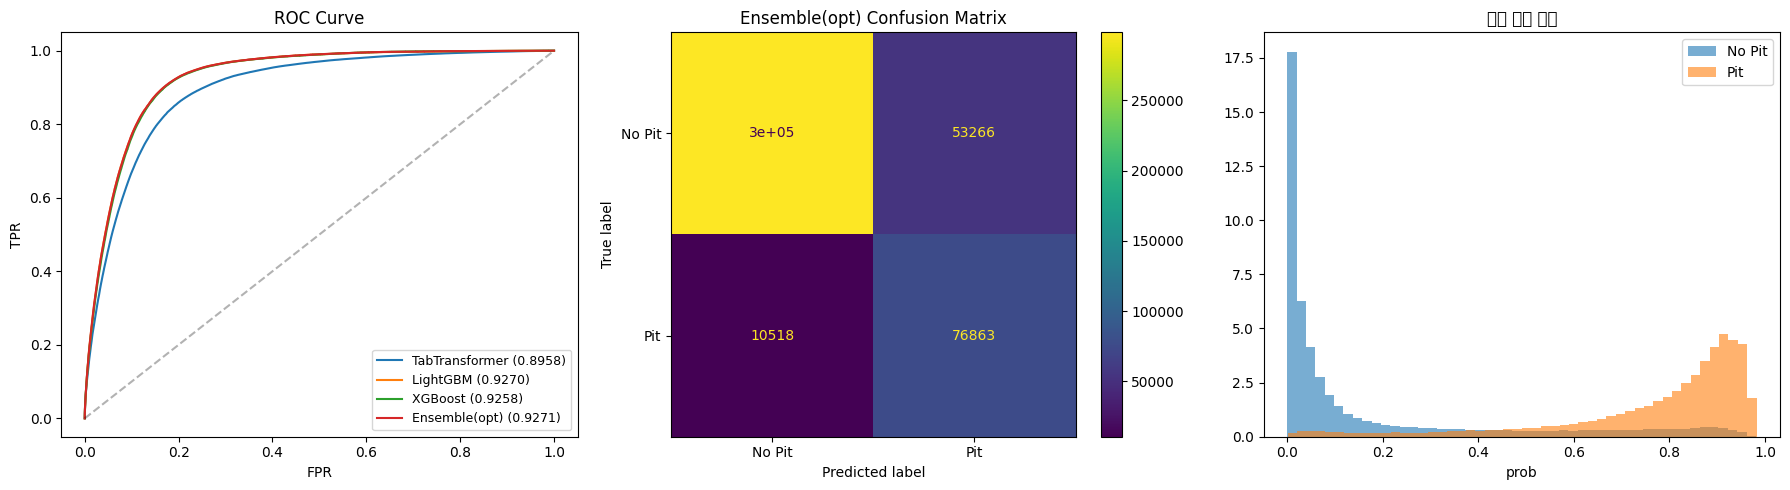

In [10]:
def f1_at(p):
    return f1_score(y, (p > 0.5).astype(int))

rows = [
    ('TabTransformer 단독', auc_tt,  f1_at(oof_tt)),
    ('LightGBM (임베딩)',   auc_lgb, f1_at(oof_lgb)),
    ('XGBoost (임베딩)',    auc_xgb, f1_at(oof_xgb)),
    ('GBDT 앙상블',         auc_gbdt, f1_at((oof_lgb + oof_xgb) / 2)),
    ('전체 앙상블 (등가중)', auc_equal, f1_at(ens_equal)),
    ('전체 앙상블 (가중최적)', best_auc_w, f1_at(oof_best)),
]
res = pd.DataFrame(rows, columns=['모델', 'OOF_AUC', 'F1'])
print(res.to_string(index=False))
print(f'\nraw+LGBM {auc_raw:.4f} | 임베딩 효용 {auc_lgb - auc_raw:+.4f} | 가중 {best_w} | gain {gain:+.4f}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for name, p in [('TabTransformer', oof_tt), ('LightGBM', oof_lgb),
                ('XGBoost', oof_xgb), ('Ensemble(opt)', oof_best)]:
    fpr, tpr, _ = roc_curve(y, p)
    axes[0].plot(fpr, tpr, label=f'{name} ({roc_auc_score(y, p):.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0].set_title('ROC Curve'); axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].legend(fontsize=9)

ConfusionMatrixDisplay.from_predictions(
    y, (oof_best > 0.5).astype(int), display_labels=['No Pit', 'Pit'], ax=axes[1])
axes[1].set_title('Ensemble(opt) Confusion Matrix')

axes[2].hist(oof_best[y == 0], bins=50, alpha=0.6, label='No Pit', density=True)
axes[2].hist(oof_best[y == 1], bins=50, alpha=0.6, label='Pit', density=True)
axes[2].set_title('예측 확률 분포'); axes[2].set_xlabel('prob'); axes[2].legend()
plt.tight_layout(); plt.show()

## 8. Test 추론 & 제출 (Step 9)

fold별 test 예측을 평균(fold bagging)한 뒤 최적 가중치로 Soft Voting.

In [11]:
tt_test  = np.mean(tt_test_folds, axis=0)
lgb_test = np.mean(lgb_test_folds, axis=0)
xgb_test = np.mean(xgb_test_folds, axis=0)

final = best_w[0] * tt_test + best_w[1] * lgb_test + best_w[2] * xgb_test
submission['PitNextLap'] = final
submission.to_csv('submission_tabtransformer_ensemble.csv', index=False)
print('saved submission_tabtransformer_ensemble.csv', submission.shape)
print(submission['PitNextLap'].describe())

saved submission_tabtransformer_ensemble.csv (188165, 2)
count    188165.000000
mean          0.295511
std           0.351279
min           0.005046
25%           0.014767
50%           0.075748
75%           0.650677
max           0.974020
Name: PitNextLap, dtype: float64
